# Self-Supervised Fruit Anomaly Detection with CH-Rand — minimal reproduction

Reproduction of **"Self-supervised Representation Learning for Reliable Robotic Monitoring of Fruit
Anomalies"** (Taeyeong Choi, Owen Would, Adrian Salazar-Gomez, Grzegorz Cielniak, **ICRA 2022**;
[arXiv:2109.10135](https://arxiv.org/abs/2109.10135)).

| | |
|---|---|
| **Author code** | [ctyeong/CH-Rand](https://github.com/ctyeong/CH-Rand) @ `e835a4508fc6ac681b1a58d8ed843292cc2cc7ec` (official release, per paper) |
| **Dataset** | [ctyeong/Riseholme-2021](https://github.com/ctyeong/Riseholme-2021) @ `ac5a03d1b42939b73e8bf888b900c7d6d0012361` (official storage, 3,520 robot-captured strawberry images) |

**What this notebook does (executed demonstration, partial scope).** It trains the paper's
**CH-Rand** self-supervised classifier on *normal* strawberries only (the pretext task: tell
original images apart from *channel-randomised* copies, paper Section III-A) using the smallest
normal scenario of the dataset (**Split1 / Ripe**, 462 images), then evaluates the paper's
*k*-nearest-neighbour distance anomaly detector (Section III-B) on the held-out Ripe test images
plus **all 153 Anomalous** strawberries, reporting AUC-ROC / AUC-PR for k = 1, 3, 5, 10
(paper Section IV-B protocol; reference Ripe values: k=1 ROC .920 / PR .955, k=5 ROC .922 /
PR .957, averaged over 3 runs).

**既存の著者実装・データセットを使い、ICRA 2022 論文の CH-Rand 自己教師あり異常検知の最小デモを再現します。**
**正常イチゴ（Ripe）だけで学習し、テスト画像＋全153枚の「異常」イチゴで kNN 距離による AUC-ROC / AUC-PR を評価します。**

**AI-assisted adaptation notice / AI改変の明示.** This notebook reuses the authors' pinned
`models.py` and `utils.py` verbatim (one Keras-3 argument rename, see below) and re-expresses the
authors' `train.py`/`test.py` loop as readable notebook cells following the same operations and
hyperparameters (`Configs/config.yaml`). The authors did not provide this Colab implementation;
documented adaptations: epoch cap 300 (paper: 1500), a single seeded run (paper: mean of 3 runs),
TensorBoard logging replaced by in-notebook plots, batched feature extraction. Untested behavior
beyond the executed example is not guaranteed.
**著者コードのピン留め版をほぼそのまま利用しつつ、Colab 向けに最小限の明示された改変（エポック上限300、1回のシード付き実行など）を加えています。**

**Scope omissions / 本デモの範囲外:** the Fresh & Stale comparison (Table III, third-party Kaggle
data + manual curation), all baselines and ablations (Tables II, V, VI), the Unripe/RU/RUO
scenarios, and 3-run averaging. One example run is **not** a verification of the paper's
dataset-level accuracy.

In [ ]:
import sys, subprocess, importlib
print("python:", sys.version.split()[0])
for mod in ["tensorflow", "keras", "torch", "torchvision", "sklearn", "PIL", "scipy"]:
    m = importlib.import_module(mod)
    print(f"{mod}: {getattr(m, '__version__', 'n/a')}")

# Runtime check: a T4 GPU is recommended; everything also runs on CPU (slower).
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("TF GPUs:", gpus)
print("Device note: with no GPU the same cells run on CPU — expect several times slower training.")

python: 3.13.15


tensorflow: 2.21.0
keras: 3.13.2


torch: 2.11.0+cu130


torchvision: 0.26.0+cu130
sklearn: 1.6.1
PIL: 11.3.0
scipy: 1.16.3
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device note: with no GPU the same cells run on CPU — expect several times slower training.


## 1 · Acquire the dataset (pinned, partial, inside Colab only)

`Riseholme-2021` @ `ac5a03d1b42939b73e8bf888b900c7d6d0012361` stores 3,520 strawberry images as PNG plus official Train/Val/Test
split files. For the minimal **Split1 / Ripe** demonstration we fetch **only** `Data/Normal/Ripe`
(462 images), `Data/Anomalous` (153 images) and `Splits/Split1` via a Git **partial clone with
sparse checkout** (`--filter=blob:none`, no LFS in this repo), checked out detached at the pinned
commit and asserted. All dataset bytes stay on the Colab VM (`/content`).

**データセットはピン留めしたコミットから部分クローンで取得します（画像は Colab 上のみに置きます）。**

In [ ]:
%%bash
set -e
cd /content
rm -rf Riseholme-2021
git clone --quiet --filter=blob:none --no-checkout --depth 1 https://github.com/ctyeong/Riseholme-2021.git
cd Riseholme-2021
git sparse-checkout set Data/Normal/Ripe Data/Anomalous Splits/Split1
git fetch --quiet --depth 1 origin ac5a03d1b42939b73e8bf888b900c7d6d0012361
git checkout --quiet ac5a03d1b42939b73e8bf888b900c7d6d0012361
echo "HEAD = $(git rev-parse HEAD)"
du -sh /content/Riseholme-2021

HEAD = ac5a03d1b42939b73e8bf888b900c7d6d0012361
14M	/content/Riseholme-2021


Verify the downloaded bytes before any scientific use: expected file counts (Ripe 462,
Anomalous 153, 12 split files — matching the dataset README statistics table) and that every PNG
parses as a valid image. **ダウンロードした画像の枚数と実体を検証します。**

In [ ]:
import glob, os
from PIL import Image

ROOT = "/content/Riseholme-2021"
assert os.path.isdir(ROOT), "dataset missing"

ripe_paths = sorted(glob.glob(f"{ROOT}/Data/Normal/Ripe/*.png"))
anom_paths = sorted(glob.glob(f"{ROOT}/Data/Anomalous/*.png"))
split_files = sorted(glob.glob(f"{ROOT}/Splits/Split1/*.txt"))
assert len(ripe_paths) == 462, f"expected 462 Ripe, got {len(ripe_paths)}"
assert len(anom_paths) == 153, f"expected 153 Anomalous, got {len(anom_paths)}"
assert len(split_files) == 12, f"expected 12 split files, got {len(split_files)}"

n_bad = 0
for p in ripe_paths + anom_paths:
    try:
        with Image.open(p) as im:
            im.load()
    except Exception:
        n_bad += 1
print(f"Ripe: {len(ripe_paths)} | Anomalous: {len(anom_paths)} | split files: {len(split_files)}")
print(f"invalid PNGs: {n_bad}")
sizes = [os.path.getsize(p) for p in ripe_paths[:5]]
print("sample sizes (bytes):", sizes)

Ripe: 462 | Anomalous: 153 | split files: 12
invalid PNGs: 0
sample sizes (bytes): [6207, 5454, 16216, 8117, 21512]


## 2 · Fetch the authors' pinned code (code-only)

`models.py` (the `Cls` classifier) and `utils.py` (CH-Rand augmentation, batching, image helpers)
are fetched **verbatim** from the official repository at the pinned commit
`e835a4508fc6ac681b1a58d8ed843292cc2cc7ec`. The single compatibility edit: Keras ≥ 3 renamed the `LeakyReLU`
argument `alpha` → `negative_slope` (identical math, paper Section III; `models.py` line 11), so
the pinned line is rewritten to avoid the deprecation warning. Everything else is untouched.

**著者コードをピン留めコミットから取得します。Keras 3 の引数名変更（alpha → negative_slope）のみ 1 行だけ互換修正します。**

In [ ]:
import urllib.request
from pathlib import Path

RAW = "https://raw.githubusercontent.com/ctyeong/CH-Rand/" + "e835a4508fc6ac681b1a58d8ed843292cc2cc7ec"
for fn in ["models.py", "utils.py"]:
    data = urllib.request.urlopen(f"{RAW}/{fn}", timeout=60).read()
    Path(f"/content/{fn}").write_bytes(data)
    print(fn, len(data), "bytes fetched")

# --- the only edit (verbatim line otherwise): models.py:11 -------------------
src = Path("/content/models.py").read_text()
old, new = "layers.LeakyReLU(alpha=.1)", "layers.LeakyReLU(negative_slope=.1)"
assert old in src
Path("/content/models.py").write_text(src.replace(old, new))
print("patched:", old, "->", new)

import sys
sys.path.insert(0, "/content")
import models, utils   # authors' modules (utils.py unchanged)
print("authors' modules imported OK")

models.py 3990 bytes fetched
utils.py 8199 bytes fetched
patched: layers.LeakyReLU(alpha=.1) -> layers.LeakyReLU(negative_slope=.1)
authors' modules imported OK


## 3 · Preview the actual input images

Before any method cell: real examples from the two classes used in this demonstration, loaded
with the authors' own `load_imgs` (resize to 64×64, `utils.py:28-36`). Top row: **Ripe**
(normal) strawberries; bottom row: **Anomalous** (health issues) — filenames shown are the
deterministic sample IDs. **実際の入力画像（正常 Ripe と異常 Anomalous）を確認します。**

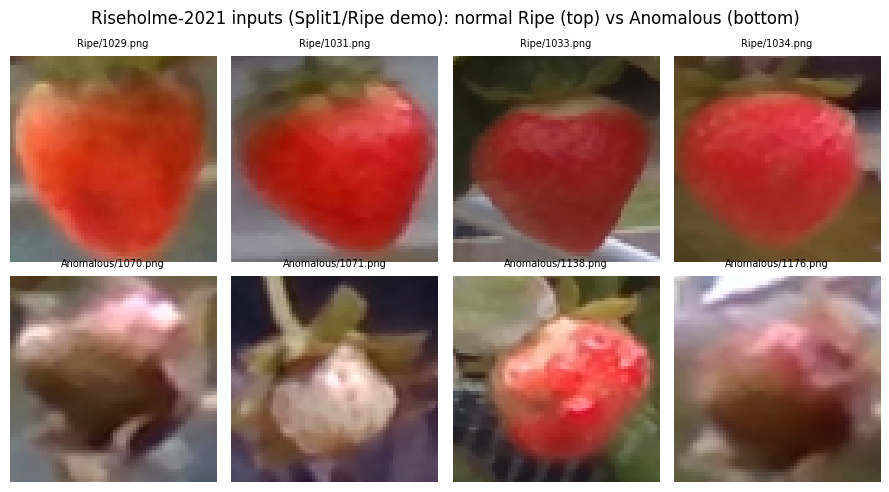

In [ ]:
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)
ripe_show = ["Ripe/" + os.path.basename(p) for p in ripe_paths[:4]]
anom_show = sorted(anom_paths)[:4]

fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for j, im in enumerate(utils.load_imgs("/content/Riseholme-2021/Data/Normal", ripe_show, 64)):
    axes[0, j].imshow(np.asarray(im)); axes[0, j].set_title(f"Ripe/{os.path.basename(ripe_show[j])}", fontsize=7)
for j, p in enumerate(anom_show):
    axes[1, j].imshow(Image.open(p).resize((64, 64))); axes[1, j].set_title(f"Anomalous/{os.path.basename(p)}", fontsize=7)
for ax in axes.ravel(): ax.axis("off")
fig.suptitle("Riseholme-2021 inputs (Split1/Ripe demo): normal Ripe (top) vs Anomalous (bottom)")
plt.tight_layout(); plt.show()

### The CH-Rand pretext transform

**Channel Randomisation** (paper Section III-A, Eq. 1–2) recolours *all* pixels with one of the
26 non-identity RGB channel mappings *with repetition* (e.g. RRR, RRG, …, BBB; the authors' table
at `utils.py:178-182`). The classifier must then separate originals (label 0) from randomised
copies (label 1) — learning representations that encode **colour regularity**, which is what
changes when fruit health degrades. The grid below shows one real Ripe input and all 26 possible
randomisations generated with the authors' own `segmentation_ch_shuffle` / channel table
(`portion=1`, i.e. all pixels affected, per `Configs/config.yaml`).

**CH-Rand は RGB チャネルを 26 通り（同一を除く・重複あり）にランダム入替える事前タスクです。**
**分類器は「元画像かチャネル入替え画像か」を当てることで、色の規則性を表す特徴を学習します。**

input: Ripe/1029.png


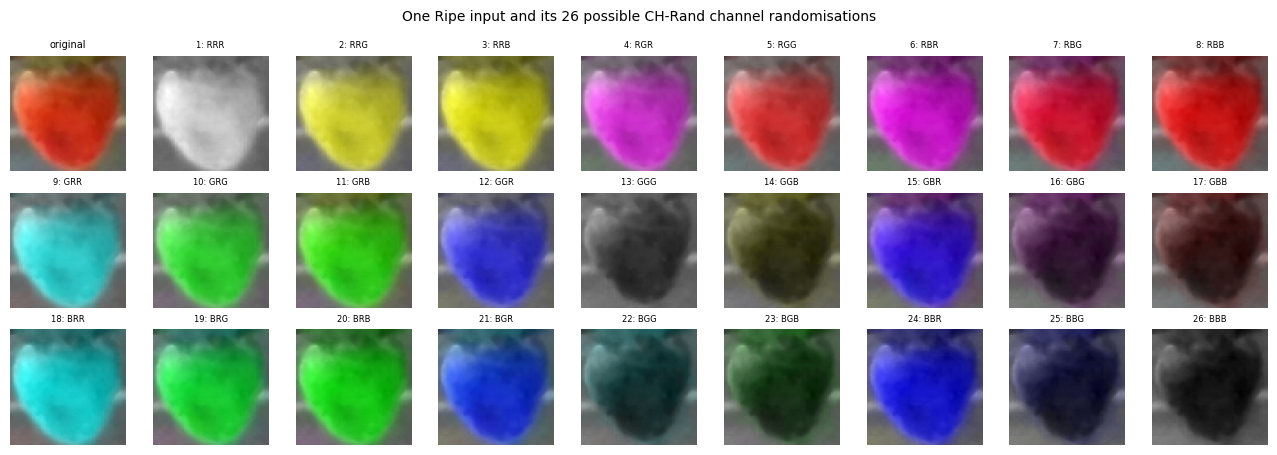

In [ ]:
# Apply each of the 26 mappings from the authors' table (utils.py:178-182) to one real image.
import numpy as np, matplotlib.pyplot as plt

chs = [[0,0,0],[0,0,1],[0,0,2],[0,1,0],[0,1,1],[0,2,0],[0,2,1],[0,2,2],
       [1,0,0],[1,0,1],[1,0,2],[1,1,0],[1,1,1],[1,1,2],[1,2,0],[1,2,1],
       [1,2,2],[2,0,0],[2,0,1],[2,0,2],[2,1,0],[2,1,1],[2,1,2],[2,2,0],
       [2,2,1],[2,2,2]]
base = np.asarray(utils.load_imgs("/content/Riseholme-2021/Data/Normal", [ripe_show[0]], 64)[0])
print("input:", ripe_show[0])

fig, axes = plt.subplots(3, 9, figsize=(13, 4.6))
axes[0, 0].imshow(base); axes[0, 0].set_title("original", fontsize=7)
for k, ax in enumerate(axes.ravel()[1:]):
    img = base.copy()
    img[:] = img[..., chs[k]]
    ax.imshow(img); ax.set_title(f"{k+1}: {''.join('RGB'[c] for c in chs[k])}", fontsize=6)
for ax in axes.ravel(): ax.axis("off")
fig.suptitle("One Ripe input and its 26 possible CH-Rand channel randomisations", fontsize=10)
plt.tight_layout(); plt.show()

## 4 · Protocol — the authors' configuration (and documented adaptations)

Values below come from the authors' `Configs/config.yaml` + `train.py`/`test.py`
(paper Section IV-B). Adaptations for this Colab demo are marked ⚠:

| Parameter | Value | Source |
|---|---|---|
| Scenario / split | Split1, R (Ripe) | config.yaml train/val/test_split |
| Image size | 64×64, standardized `x/127.5 − 1` | config img_size; utils.standardize |
| Aug mode | CH-Rand, `portion=1.` (all pixels) | config aug_mode/portion |
| Batch / updates per epoch | 128 × 8 | config batch_size, epoch_size |
| Learning rate (Adam) | 5e-6, ×3/4 every 200 epochs | config lr; utils.scheduler |
| Validation / test interval | every 30 epochs | config val_interval, test_interval |
| Early stop | mean of last 5 val accs > .95 | config val_acc_threshold, stop_criterion |
| Features for kNN | fc layer (`fc_feat: True` → Dense 256) | config fc_feat; models.feature |
| k (neighbors) | 1, 3, 5, 10 | config n_neighbors |
| ⚠ Epoch cap | **300** (paper/config: 1500) | demo runtime budget |
| ⚠ Runs | **1 seeded run** (paper: mean of 3) | demo |
| ⚠ Validation | `model.evaluate` on a fresh val batch every 30 epochs (equivalent to the authors' `validation_data` on the same schedule) | restructured loop |
| ⚠ TensorBoard | omitted; progress curves plotted in-notebook instead | demo |

**著者の config.yaml の値をそのまま使い、デモ向けにエポック上限（300）と 1 回のシード付き実行のみを変更しています。**

### Load the split files and images

Split1/Ripe assigns 70/10/20% of the 462 normal (Ripe) images to train/val/test; **all 153
Anomalous images are used for testing only** (one-class setting, dataset README "Random Splits").
Paths inside the split files are relative to `Data/Normal` (e.g. `Ripe/1029.png`).
**各 split の画像を読み込みます。異常画像はテスト専用です。**

In [ ]:
import glob, random
import numpy as np

random.seed(0); np.random.seed(0)
import tensorflow as tf
tf.keras.utils.set_random_seed(0)   # one seeded run (paper averages 3 unseeded runs)

SPLIT = "/content/Riseholme-2021/Splits/Split1"
NORMAL = "/content/Riseholme-2021/Data/Normal"
IMG_SIZE = 64

train_paths = utils.load_img_paths(f"{SPLIT}/Split1-R-Train.txt")
val_paths   = utils.load_img_paths(f"{SPLIT}/Split1-R-Val.txt")
test_paths  = utils.load_img_paths(f"{SPLIT}/Split1-R-Test.txt")

train_x = utils.load_imgs(NORMAL, train_paths, IMG_SIZE)
val_x   = utils.load_imgs(NORMAL, val_paths, IMG_SIZE)
test_norm_x = utils.load_imgs(NORMAL, test_paths, IMG_SIZE)
test_anom_x = [Image.open(p).resize((IMG_SIZE, IMG_SIZE)) for p in anom_paths]

print(f"train: {len(train_x)} | val: {len(val_x)} | test normal: {len(test_norm_x)} | test anomalous: {len(test_anom_x)}")
assert len(train_x) > 0 and len(test_anom_x) == 153

train: 323 | val: 46 | test normal: 93 | test anomalous: 153


### Traditional augmentations

Exactly as in `train.py:80-83`: every image (original *and* randomised half) also receives
torchvision ColorJitter(0.1 each) + random horizontal/vertical flips — the "traditional
augmentation" on top of the CH-Rand pretext transform.
**著者どおり、ColorJitter＋ランダム左右/上下反転を全画像に適用します。**

In [ ]:
import torchvision
color_jitter = torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1)
h_flip = torchvision.transforms.RandomHorizontalFlip()
v_flip = torchvision.transforms.RandomVerticalFlip()
augmentations = [color_jitter, h_flip, v_flip]   # train.py:83

## 5 · Create the classifier (authors' `models.py`)

`Cls` is the paper's 5-conv-layer classifier (64→128→256→512→512 filters, 3×3, LeakyReLU 0.1,
BatchNorm, max/avg pooling) with two dense layers (256, sigmoid output) and L2 1e-3
(`models.py:6-77`). `feature(..., fc_out=True)` returns the **fc** 256-d activations used for the
kNN detector (config `fc_feat: True`). Compiled with Adam lr 5e-6 and binary cross-entropy, as in
`train.py:57-60`. **著者のモデル定義をそのままビルドします。**

In [ ]:
from tensorflow import keras

model = models.Cls(n_cls=1)                 # authors' class, imported from pinned models.py
model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
model.compile(loss=['binary_crossentropy'], metrics=['accuracy'],
              optimizer=keras.optimizers.Adam(learning_rate=5e-6))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cls', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### kNN evaluation helpers

Batched (behavior-preserving) port of the feature extraction in `train.py:117-137` / `test.py:54-74`
and the distance/AUC computation in `train.py:139-155` / `test.py:76-95`: standardize → `feature`
→ mean Euclidean distance to the k nearest *training* representations → AUC-ROC / AUC-PR.
**特徴抽出はバッチ化していますが計算内容は著者コードと同一です（kNN 平均距離 → AUC）。**

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def extract_features(imgs, bs=128):
    arr = np.stack([utils.standardize(im) for im in imgs]).astype('float32')
    outs = [model.feature(arr[i:i+bs], training=False, fc_out=True) for i in range(0, len(arr), bs)]
    return np.concatenate(outs, axis=0)

def knn_auc(train_x, test_norm_x, test_anom_x, ks=(1, 3, 5, 10)):
    tr = extract_features(train_x)
    tn = extract_features(test_norm_x)
    ta = extract_features(test_anom_x)
    results, dists = {}, {}
    for k in ks:
        neigh = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(tr)   # train.py:142-143
        d_norm = np.mean(neigh.kneighbors(tn)[0], -1)                      # mean over k neighbors
        d_anom = np.mean(neigh.kneighbors(ta)[0], -1)
        y_hats = np.concatenate([d_norm, d_anom])
        labels = [0] * len(tn) + [1] * len(ta)
        fpr, tpr, _ = roc_curve(labels, y_hats)
        pre, rec, _ = precision_recall_curve(labels, y_hats)
        results[k] = (auc(fpr, tpr), auc(rec, pre))
        dists[k] = (d_norm, d_anom)
    return results, dists

### Train the CH-Rand pretext classifier (restructured authors' `train.py:88-182`)

Each epoch: sample 8×128 images with replacement, build the 50/50 original-vs-randomised batch
with the authors' `utils.get_xy` (`n_processors=1` equivalent), and take 8 Adam steps. Every 30
epochs: evaluate on a fresh validation batch (authors' `validation_data` schedule), save weights
when validation accuracy improves (authors save the max-val-acc model), and run the kNN AUC probe
on the *current* weights. Training stops early if the mean of the last 5 validation accuracies
exceeds 0.95 (authors' stopping rule) or at the 300-epoch cap.

**各エポックで著者の `get_xy` により 50/50 バッチを作り 8 ステップ学習します。30 エポックごとに検証と AUC 評価、最高 val accuracy モデルの保存を行います。**

In [ ]:
import gc, time

N_EPOCHS, BATCH, EPOCH_SIZE = 300, 128, 8     # paper config: 1500 epochs (capped for this demo)
VAL_INTERVAL, TEST_INTERVAL = 30, 30
VAL_ACC_THRESHOLD, STOP_CRITERION = .95, 5
BEST_PATH = "/content/ch_rand_best.weights.h5"

def build_batch(pool):
    imgs = random.choices(pool, k=BATCH * EPOCH_SIZE)          # train.py:95
    return utils.get_xy(imgs, mode='CH-Rand', in_size=(IMG_SIZE, IMG_SIZE, 3),
                        augmentations=augmentations, jitter=color_jitter, delta=1.)  # portion=1

val_accs, max_acc, log_rows = [], -1.0, []
lr_current = 5e-6
t0 = time.time()
for e in range(N_EPOCHS):
    if (e + 1) % 200 == 0:                                     # authors' utils.scheduler
        lr_current *= 3 / 4
    model.optimizer.learning_rate.assign(lr_current)
    gc.collect()                                               # train.py:92

    x_ag, y_ag = build_batch(train_x)
    h = model.fit(x_ag, y_ag, batch_size=BATCH, epochs=1, verbose=0)

    if (e + 1) % VAL_INTERVAL == 0:                            # validation schedule
        vx, vy = build_batch(val_x)
        val_loss, val_acc = model.evaluate(vx, vy, batch_size=BATCH, verbose=0)
        val_accs.append(val_acc)
        if val_acc >= max_acc:                                 # keep max-val-acc weights
            max_acc = val_acc
            model.save_weights(BEST_PATH)
        if len(val_accs) >= STOP_CRITERION and np.mean(val_accs[-STOP_CRITERION:]) > VAL_ACC_THRESHOLD:
            print(f"early stop at epoch {e+1}: mean last-5 val acc {np.mean(val_accs[-5:]):.3f} > {VAL_ACC_THRESHOLD}")
            break

    if (e + 1) % TEST_INTERVAL == 0:                           # AUC probe on current weights
        res, _ = knn_auc(train_x, test_norm_x, test_anom_x, ks=(1, 5))
        log_rows.append({"epoch": e + 1, "train_acc": float(h.history['accuracy'][0]),
                         "val_acc_max": max_acc,
                         "k1_roc": res[1][0], "k1_pr": res[1][1],
                         "k5_roc": res[5][0], "k5_pr": res[5][1]})
        r = log_rows[-1]
        print(f"epoch {r['epoch']:3d} | train_acc {r['train_acc']:.3f} | max val acc {r['val_acc_max']:.3f} "
              f"| k=1 ROC {r['k1_roc']:.3f} PR {r['k1_pr']:.3f} | k=5 ROC {r['k5_roc']:.3f} PR {r['k5_pr']:.3f}")

print(f"training finished in {(time.time()-t0)/60:.1f} min; saved best (max val acc) weights at {BEST_PATH}")

epoch  30 | train_acc 0.941 | max val acc 0.733 | k=1 ROC 0.912 PR 0.949 | k=5 ROC 0.932 PR 0.963


epoch  60 | train_acc 0.977 | max val acc 0.940 | k=1 ROC 0.927 PR 0.960 | k=5 ROC 0.934 PR 0.965


epoch  90 | train_acc 0.974 | max val acc 0.954 | k=1 ROC 0.921 PR 0.958 | k=5 ROC 0.924 PR 0.960


epoch 120 | train_acc 0.986 | max val acc 0.966 | k=1 ROC 0.926 PR 0.961 | k=5 ROC 0.924 PR 0.961


epoch 150 | train_acc 0.984 | max val acc 0.980 | k=1 ROC 0.924 PR 0.960 | k=5 ROC 0.924 PR 0.961


early stop at epoch 180: mean last-5 val acc 0.964 > 0.95
training finished in 8.2 min; saved best (max val acc) weights at /content/ch_rand_best.weights.h5


### Training progress

Plot the recorded per-30-epoch probes: pretext-task training accuracy and validation accuracy,
plus the kNN detector's AUC on the current features. This visualizes how the self-supervised
pretext task and the anomaly detection performance evolve — a visualization created for this
notebook, not an author figure. **事前タスク精度と AUC の推移を可視化します（本ノートブック独自の図）。**

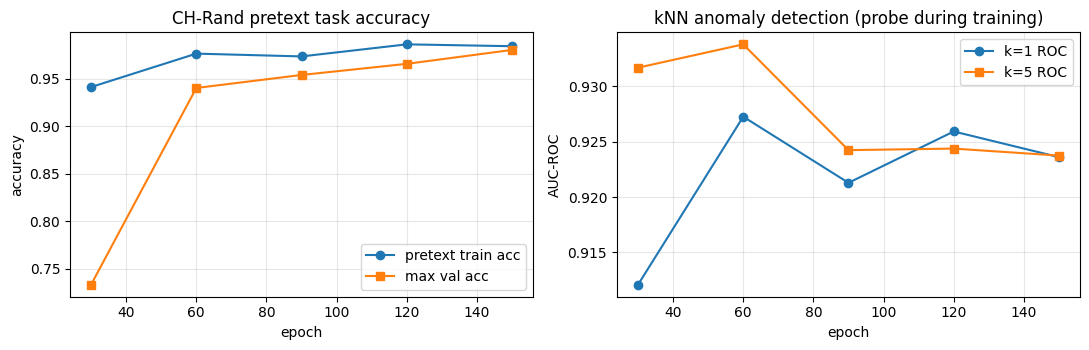

,epoch,train_acc,val_acc_max,k1_roc,k1_pr,k5_roc,k5_pr
0,30,0.941406,0.733398,0.912081,0.948931,0.931689,0.962902
1,60,0.976562,0.940430,0.927261,0.959579,0.933797,0.964672
2,90,0.973633,0.954102,0.921288,0.958325,0.924239,0.960188
3,120,0.986328,0.965820,0.925926,0.960752,0.924380,0.960567
4,150,0.984375,0.980469,0.923607,0.959712,0.923747,0.960588


In [ ]:
import pandas as pd
progress_df = pd.DataFrame(log_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(progress_df.epoch, progress_df.train_acc, 'o-', label='pretext train acc')
axes[0].plot(progress_df.epoch, progress_df.val_acc_max, 's-', label='max val acc')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('CH-Rand pretext task accuracy')
axes[1].plot(progress_df.epoch, progress_df.k1_roc, 'o-', label='k=1 ROC')
axes[1].plot(progress_df.epoch, progress_df.k5_roc, 's-', label='k=5 ROC')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('AUC-ROC'); axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].set_title('kNN anomaly detection (probe during training)')
plt.tight_layout(); plt.show()
display(progress_df)

## 6 · Final evaluation (the authors' `test.py` path)

Reload the **best** saved weights (max validation accuracy — the model the authors' workflow
would keep), extract fc features for train / test-normal / test-anomalous images, and compute
AUC-ROC / AUC-PR for k = 1, 3, 5, 10. Paper reference for Split1/**Ripe** (mean of 3 runs,
CH-Rand README table): **k=1 ROC .920 / PR .955; k=5 ROC .922 / PR .957**.
**保存済みの最良重みを読み込み、test.py と同じ手順で AUC を評価します。**

In [ ]:
model.load_weights(BEST_PATH)
final_results, final_dists = knn_auc(train_x, test_norm_x, test_anom_x, ks=(1, 3, 5, 10))
paper_ref = {1: ('.920', '.955'), 5: ('.922', '.957')}   # CH-Rand README, Split1 Ripe, CH-Rand columns
rows = []
for k, (roc, pr) in final_results.items():
    ref_roc, ref_pr = paper_ref.get(k, ('—', '—'))
    rows.append({'k neighbors': k, 'AUC-ROC (this run)': round(roc, 3),
                 'AUC-PR (this run)': round(pr, 3),
                 'ROC (paper, mean of 3)': ref_roc, 'PR (paper, mean of 3)': ref_pr})
results_df = pd.DataFrame(rows)
print('Final evaluation (best val-acc weights):')
display(results_df)

Final evaluation (best val-acc weights):


,k neighbors,AUC-ROC (this run),AUC-PR (this run),"ROC (paper, mean of 3)","PR (paper, mean of 3)"
0,1,0.924,0.960,.920,.955
1,3,0.925,0.961,—,—
2,5,0.924,0.961,.922,.957
3,10,0.922,0.960,—,—


### ROC and precision-recall curves

Curves from the actual saved outputs of this run (k = 1 and k = 5). The detector scores images by
mean kNN distance to normal training features; higher score ⇒ more anomalous.
**この実行の実際の出力から ROC / PR 曲線を描きます。**

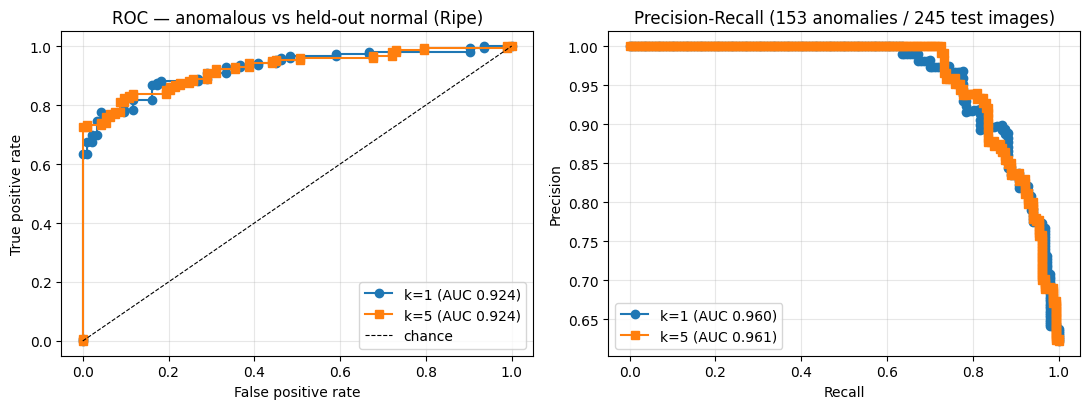

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
tn_feats, ta_feats = extract_features(test_norm_x), extract_features(test_anom_x)
tr_feats = extract_features(train_x)
labels = [0] * len(tn_feats) + [1] * len(ta_feats)
for k, style in zip((1, 5), ('o-', 's-')):
    neigh = NearestNeighbors(n_neighbors=k).fit(tr_feats)
    scores = np.concatenate([np.mean(neigh.kneighbors(tn_feats)[0], -1),
                             np.mean(neigh.kneighbors(ta_feats)[0], -1)])
    fpr, tpr, _ = roc_curve(labels, scores)
    pre, rec, _ = precision_recall_curve(labels, scores)
    axes[0].plot(fpr, tpr, style, label=f'k={k} (AUC {final_results[k][0]:.3f})')
    axes[1].plot(rec, pre, style, label=f'k={k} (AUC {final_results[k][1]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=.8, label='chance')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC — anomalous vs held-out normal (Ripe)'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (153 anomalies / 245 test images)'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Anomaly-score distributions

Distribution of the k=1 mean-NN-distance scores for held-out **normal** (Ripe test) vs
**anomalous** strawberries. With a well-trained CH-Rand feature space, anomalous fruit should
shift toward larger distances. **正常/異常の kNN 距離スコアの分布を比較します。**

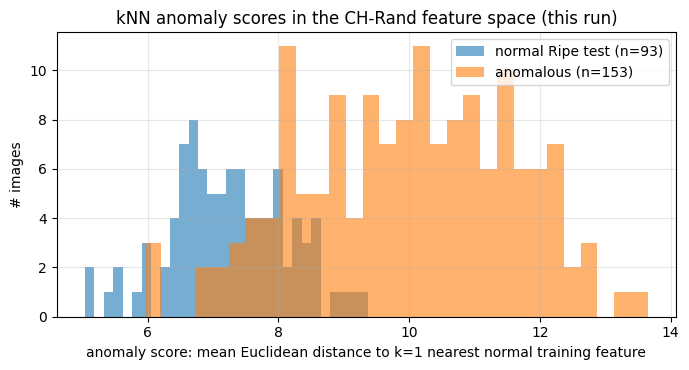

In [ ]:
d_norm, d_anom = final_dists[1]
plt.figure(figsize=(7, 3.8))
plt.hist(d_norm, bins=30, alpha=.6, label=f'normal Ripe test (n={len(d_norm)})')
plt.hist(d_anom, bins=30, alpha=.6, label=f'anomalous (n={len(d_anom)})')
plt.xlabel('anomaly score: mean Euclidean distance to k=1 nearest normal training feature')
plt.ylabel('# images'); plt.legend(); plt.grid(alpha=.3)
plt.title('kNN anomaly scores in the CH-Rand feature space (this run)')
plt.tight_layout(); plt.show()

### Export results

Save the final metrics as CSV inside the Colab VM (`/content`) and print it for the record.
**結果を CSV に保存します。**

In [ ]:
results_df.to_csv('/content/ch_rand_ripe_split1_results.csv', index=False)
print(open('/content/ch_rand_ripe_split1_results.csv').read())

k neighbors,AUC-ROC (this run),AUC-PR (this run),"ROC (paper, mean of 3)","PR (paper, mean of 3)"
1,0.924,0.96,.920,.955
3,0.925,0.961,—,—
5,0.924,0.961,.922,.957
10,0.922,0.96,—,—



## 7 · Interpretation, limitations, references

**How to read the result.** Compare the printed AUCs with the paper's Split1 **Ripe** reference
(k=1 ROC .920 / PR .955; k=5 ROC .922 / PR .957 — means over 3 unseeded runs). This notebook
reports **one seeded run with a 300-epoch cap** (paper protocol: up to 1500 epochs), so moderate
deviations are expected; the qualitative claim — colour-based CH-Rand features separate anomalous
strawberries from held-out normals far better than chance — is what the demo can support.

**結果の見方:** 本デモは 1 回のシード付き実行（300 エポック上限）であり、論文の値（3 回平均・
1500 エポック）と完全一致は期待できません。偶然（AUC 0.5）より十分高いかで主張を評価してください。

**Limitations / 制限事項**
- Partial demonstration: Split1 + Ripe scenario only; no Fresh & Stale, no baselines/ablations.
- 300-epoch cap and single run (documented above); paper AUCs are 3-run averages.
- Neither repository declares a license (GitHub API: null); content is fetched from the authors'
  own pinned URLs for this demonstration — check reuse terms with the authors before
  redistribution.
- The publisher/IEEE version of record was not used; arXiv v2 + official code are the verified
  sources here.

**References**
1. Choi, Would, Salazar-Gomez, Cielniak, *"Self-supervised Representation Learning for Reliable
   Robotic Monitoring of Fruit Anomalies"*, ICRA 2022. [arXiv:2109.10135](https://arxiv.org/abs/2109.10135)
2. Official code: [ctyeong/CH-Rand](https://github.com/ctyeong/CH-Rand) @ `e835a4508fc6ac681b1a58d8ed843292cc2cc7ec`
3. Dataset: [ctyeong/Riseholme-2021](https://github.com/ctyeong/Riseholme-2021) @ `ac5a03d1b42939b73e8bf888b900c7d6d0012361`
4. Extended journal version: Choi et al., *Channel Randomisation…*, Computers and Electronics in
   Agriculture 226:109416, 2024.